In [95]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
import matplotlib.pyplot as plt

In [96]:
url = "https://archive.ics.uci.edu/static/public/12/data.csv"
df=pd.read_csv(url,header=0)
print(df.head())  
print(len(df))
print(df.shape)
#Torque=weight×distance
#If left torque > right torque → L
#If right torque > left torque → R
#If equal → B

  class  left-weight  left-distance  right-weight  right-distance
0     B            1              1             1               1
1     R            1              1             1               2
2     R            1              1             1               3
3     R            1              1             1               4
4     R            1              1             1               5
625
(625, 5)


In [98]:
##Check for null or NAN values
#for col in df.columns:
   # null_count=df[col].isna().sum()
    #print(f" {col} has {null_count} null values" )

null_df = pd.DataFrame({
    'column_name': df.columns,
    'null_count': df.isna().sum().values
})

print(null_df)

      column_name  null_count
0           class           0
1     left-weight           0
2   left-distance           0
3    right-weight           0
4  right-distance           0


## Split Data Train Test

In [99]:
X = df.iloc[:, 1:5].values #except the first column
Y = df.iloc[:, 0].values
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=100,stratify=y) 
#stratify=y, stratified train - test split to maintain the proportion of categories within train and test data.

# Train using Gini

In [100]:
model_gini=DecisionTreeClassifier(criterion='gini',max_depth=3,min_samples_leaf=5,random_state=100)
model_gini.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,100
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# Train using Entropy

In [101]:
model_entropy=DecisionTreeClassifier(criterion='entropy',max_depth=3,min_samples_leaf=5,random_state=100)
model_entropy.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,100
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [102]:
y_pred_gini=model_gini.predict(X_test)
y_pred_entropy=model_entropy.predict(X_test)

In [103]:
def calculate_accuracy(y_test,y_pred):
    print("\n Confusion Matrix \n", confusion_matrix(y_test,y_pred))
    print("\n Accuracy Score \n", accuracy_score(y_test, y_pred) * 100)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [104]:
#Accuracy for model_gini
calculate_accuracy(y_test,y_pred_gini)


 Confusion Matrix 
 [[ 0  7  3]
 [ 0 45 13]
 [ 0  9 48]]

 Accuracy Score 
 74.4

Classification Report:
               precision    recall  f1-score   support

           B       0.00      0.00      0.00        10
           L       0.74      0.78      0.76        58
           R       0.75      0.84      0.79        57

    accuracy                           0.74       125
   macro avg       0.50      0.54      0.52       125
weighted avg       0.68      0.74      0.71       125



C:\Users\Ashutosh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Ashutosh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Ashutosh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [105]:
#Accuracy for model_entropy
calculate_accuracy(y_test,y_pred_entropy)


 Confusion Matrix 
 [[ 0  6  4]
 [ 0 40 18]
 [ 0  8 49]]

 Accuracy Score 
 71.2

Classification Report:
               precision    recall  f1-score   support

           B       0.00      0.00      0.00        10
           L       0.74      0.69      0.71        58
           R       0.69      0.86      0.77        57

    accuracy                           0.71       125
   macro avg       0.48      0.52      0.49       125
weighted avg       0.66      0.71      0.68       125



C:\Users\Ashutosh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Ashutosh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Ashutosh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [106]:
def plot_decision_tree (model_name,feature_names,class_names):
    plt.figure(figsize=(15,10))
    plot_tree(model_name,filled=True,feature_names=feature_names, class_names=class_names, rounded=True)
    plt.show()

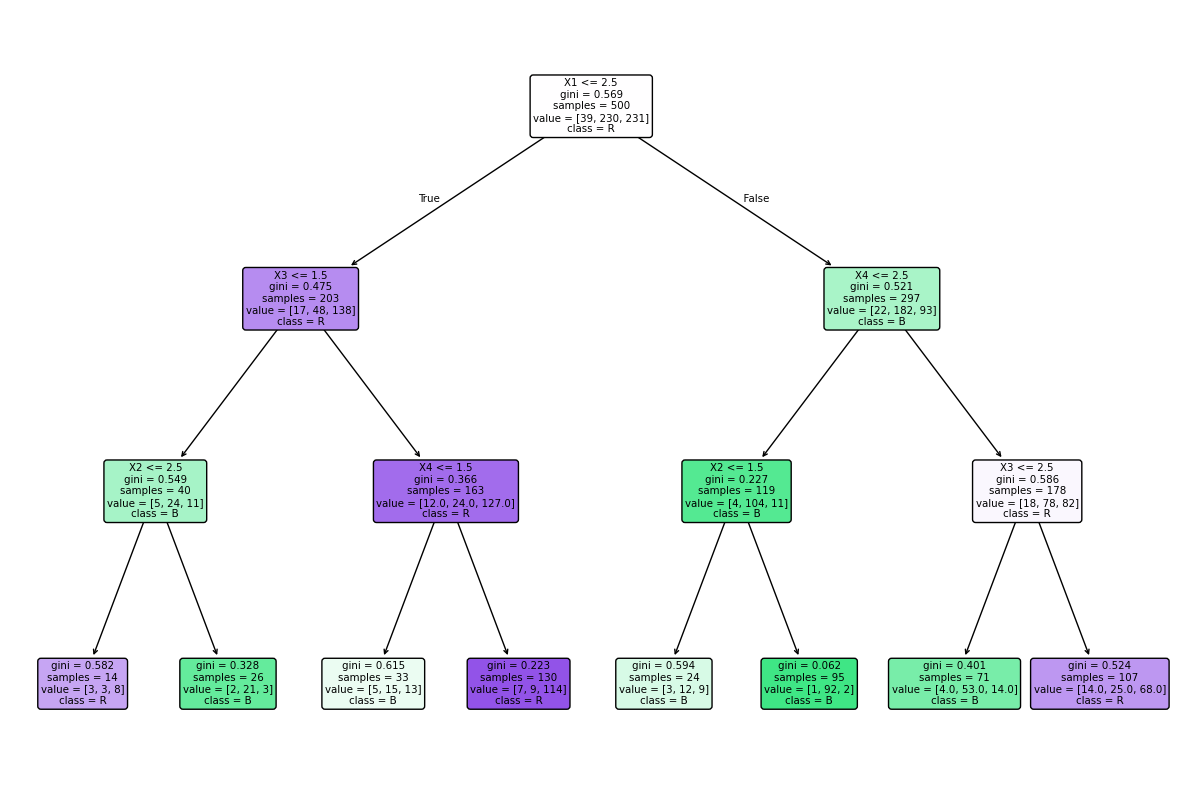

In [107]:
##plot for model_gini
plot_decision_tree(model_gini,['X1', 'X2', 'X3', 'X4'],['L', 'B', 'R'])

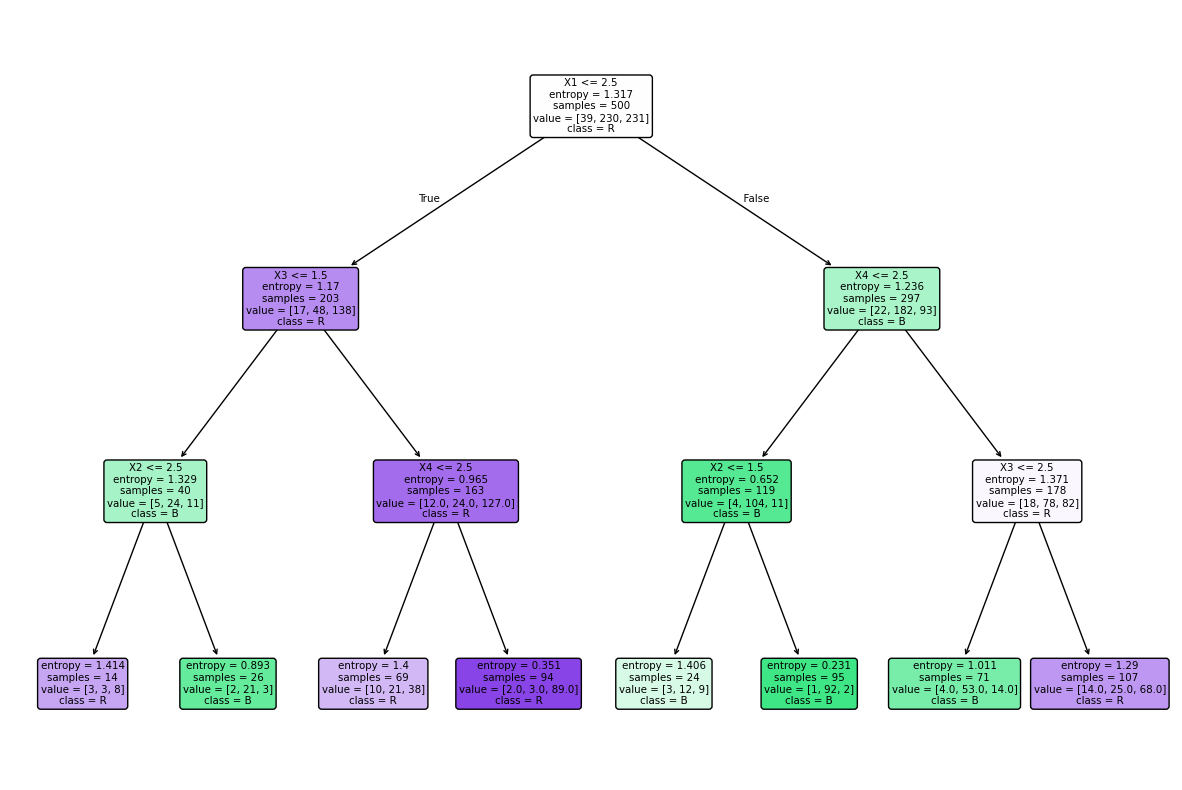

In [108]:
##plot for model_gini
plot_decision_tree(model_entropy,['X1', 'X2', 'X3', 'X4'],['L', 'B', 'R'])

# Random Forest Implementation

In [109]:
from sklearn.ensemble import RandomForestClassifier

In [110]:
# Features and target
X = df.drop('class', axis=1)
y = df['class']

In [111]:
# Train-test split (IMPORTANT: use stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=100, stratify=y
)
#stratify=y, stratified train - test split to maintain the proportion of categories within train and test data
# Here one category is less so it is used.

In [112]:
random_forest=RandomForestClassifier(n_estimators=100,criterion='gini',random_state=100,class_weight='balanced')
random_forest.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [113]:
y_pred_rf=random_forest.predict(X_test)

In [114]:
calculate_accuracy(y_test,y_pred_rf)


 Confusion Matrix 
 [[ 0  5  5]
 [ 3 55  0]
 [ 2  1 54]]

 Accuracy Score 
 87.2

Classification Report:
               precision    recall  f1-score   support

           B       0.00      0.00      0.00        10
           L       0.90      0.95      0.92        58
           R       0.92      0.95      0.93        57

    accuracy                           0.87       125
   macro avg       0.61      0.63      0.62       125
weighted avg       0.84      0.87      0.85       125



# Gradient Boost Implementation

In [115]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=100)
gb_model.fit(X_train, y_train)

y_pred_gb= gb_model.predict(X_test)

In [116]:
calculate_accuracy(y_test,y_pred_gb)


 Confusion Matrix 
 [[ 0  6  4]
 [ 2 56  0]
 [ 1  0 56]]

 Accuracy Score 
 89.60000000000001

Classification Report:
               precision    recall  f1-score   support

           B       0.00      0.00      0.00        10
           L       0.90      0.97      0.93        58
           R       0.93      0.98      0.96        57

    accuracy                           0.90       125
   macro avg       0.61      0.65      0.63       125
weighted avg       0.84      0.90      0.87       125



In [83]:
#pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.7 MB/s eta 0:00:59
   ---------------------------------------- 1.0/101.7 MB 2.0 MB/s eta 0:00:50
    --------------------------------------- 1.6/101.7 MB 2.0 MB/s eta 0:00:51
    --------------------------------------- 1.8/101.7 MB 2.0 MB/s eta 0:00:51
    --------------------------------------- 2.4/101.7 MB 1.9 MB/s eta 0:00:53
    --------------------------------------- 2.4/101.7 MB 1.9 MB/s eta 0:00:53
   - -------------------------------------- 3.1/101.7 MB 1.9 MB/s eta 0:00:54
   - -------------------------------------- 3.4/101.7 MB 1.9 MB/s eta 0:00:53
   - -------------------------------------- 3.9/101.7 MB 1.9 MB/s eta 0:00:53
   - -------------------------------------- 4.5/101.7 MB 1.9 MB/s eta 0:00:52
   - -------------------------------------- 4.7/101.7 MB 1.9 MB/s eta 0:00:52


In [117]:
#XGBoost needed numeric labels rather than strings
mapping={'B':0,'L':1,'R':2}
y_numeric=df['class'].map(mapping)

In [118]:
X_train, X_test, y_numeric_train, y_numeric_test = train_test_split(
    X, y_numeric, test_size=0.2, random_state=100, stratify=y_numeric
)

In [119]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=100
)

xgb_model.fit(X_train, y_numeric_train)
y_pred_xgb = xgb_model.predict(X_test)

In [120]:
calculate_accuracy(y_numeric_test,y_pred_xgb)


 Confusion Matrix 
 [[ 2  5  3]
 [ 2 56  0]
 [ 2  1 54]]

 Accuracy Score 
 89.60000000000001

Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.20      0.25        10
           1       0.90      0.97      0.93        58
           2       0.95      0.95      0.95        57

    accuracy                           0.90       125
   macro avg       0.73      0.70      0.71       125
weighted avg       0.88      0.90      0.89       125



In [ ]:
#"Tree-based ensemble models like Random Forest and Extra Trees performed best. 
#Boosting methods did not significantly improve performance due to the deterministic nature of the dataset."

# Extremely Randomized Trees Implementation 

In [121]:
from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(
    n_estimators=100,
    random_state=100
)

et_model.fit(X_train, y_train)

y_pred_et = et_model.predict(X_test)

In [123]:
calculate_accuracy(y_test,y_pred_et)


 Confusion Matrix 
 [[ 0  5  5]
 [ 6 52  0]
 [ 2  1 54]]

 Accuracy Score 
 84.8

Classification Report:
               precision    recall  f1-score   support

           B       0.00      0.00      0.00        10
           L       0.90      0.90      0.90        58
           R       0.92      0.95      0.93        57

    accuracy                           0.85       125
   macro avg       0.60      0.61      0.61       125
weighted avg       0.83      0.85      0.84       125



# SVM implementation

In [124]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [125]:
#Feature scaling needed here
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [126]:
model_svm=SVC(kernel='linear',C=1.0,random_state=100)
model_svm.fit(X_train_scaled,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [127]:
y_pred_svm=model_svm.predict(X_test_scaled)
calculate_accuracy(y_test,y_pred_svm)


 Confusion Matrix 
 [[10  0  0]
 [ 0 57  1]
 [ 4  1 52]]

 Accuracy Score 
 95.19999999999999

Classification Report:
               precision    recall  f1-score   support

           B       0.71      1.00      0.83        10
           L       0.98      0.98      0.98        58
           R       0.98      0.91      0.95        57

    accuracy                           0.95       125
   macro avg       0.89      0.97      0.92       125
weighted avg       0.96      0.95      0.95       125



In [130]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []

def evaluate_model(name, y_test, y_pred):
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    })

# Add all models
evaluate_model("Decision Tree", y_test, y_pred_gini)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("Extremely Randomized Trees", y_test, y_pred_et)
evaluate_model("Gradient Boosting", y_test, y_pred_gb)
evaluate_model("XGradient Boosting", y_numeric_test, y_pred_xgb)
evaluate_model("SVM", y_test, y_pred_svm)

# Create DataFrame
comparison_df = pd.DataFrame(results)

print(comparison_df)

                        Model  Accuracy  Precision  Recall  F1 Score
0               Decision Tree     0.744   0.684295   0.744  0.712709
1               Random Forest     0.872   0.835717   0.872  0.853459
2  Extremely Randomized Trees     0.848   0.833356   0.848  0.840552
3           Gradient Boosting     0.896   0.844697   0.896  0.869579
4          XGradient Boosting     0.896   0.877763   0.896  0.885067
5                         SVM     0.952   0.960539   0.952  0.953794


C:\Users\Ashutosh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
